## Modified embedding and built in block

In [1]:
import torch
import torch.nn as nn
import numpy as np
import math
import torch.nn.functional as F 

DIM      = 384
EXPANDED_DIM = 256
N_HEADS  = 16
N_LAYERS = 16
FFN_DIM  = 512
HEAD_DIM = DIM // N_HEADS 

def sinusoidal_encoding(seq_len, dim, device):
    pe       = torch.zeros(seq_len, dim, device=device)
    position = torch.arange(seq_len, device=device).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * (-math.log(10000.0) / dim))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # (seq_len, dim)


class MicroLM(nn.Module):
    """
    MicroLM using PyTorch built-in TransformerEncoderLayer.

    Flow:
      token_ids
        -> frozen embedding_table lookup
        -> expander: 384 -> 512
        -> sinusoidal positional encoding
        -> N transformer encoder layers with causal mask
        -> final LayerNorm
        -> output_head
    """

    def __init__(self):
        super().__init__()

        # Frozen MiniLM-style embedding table
        self.register_buffer("embedding_table", embedding_tensor)

        # Expander 384 -> 512
        self.expander = nn.Sequential(
            nn.Linear(MINILM_DIM, EXPANDED_DIM),
            nn.LayerNorm(EXPANDED_DIM),
        )

        # Built-in transformer block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=EXPANDED_DIM,
            nhead=N_HEADS,
            dim_feedforward=FFN_DIM,
            dropout=0.1,
            activation="gelu",
            batch_first=True,     # input/output shape: (B, T, D)
            norm_first=True       # pre-norm, same style as your original block
            
        )

        self.blocks = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=N_LAYERS
        )

        self.norm = nn.LayerNorm(EXPANDED_DIM)
        self.output_head = nn.Linear(EXPANDED_DIM, VOCAB_SIZE, bias=False)

    def make_causal_mask(self, T, device):
        """
        PyTorch Transformer expects mask shape: (T, T)

        True means blocked when using bool mask.
        So upper triangle = True.
        """
        return torch.triu(
            torch.ones(T, T, device=device, dtype=torch.bool),
            diagonal=1
        )

    def forward(self, token_ids):
        B, T = token_ids.shape

        # (B, T, 384)
        x = self.embedding_table[token_ids]

        # (B, T, 512)
        x = self.expander(x)

        # Add positional encoding
        x = x + sinusoidal_encoding(T, EXPANDED_DIM, token_ids.device)

        # Causal mask for GPT-style left-to-right generation
        causal_mask = self.make_causal_mask(T, token_ids.device)

        # (B, T, 512)
        x = self.blocks(x, mask=causal_mask)

        x = self.norm(x)

        # (B, T, VOCAB_SIZE)
        logits = self.output_head(x)

        return logits

embedding_table = np.load("tokenizer/token_embeddings.npy")
embedding_tensor = torch.tensor(embedding_table, dtype=torch.float32)

VOCAB_SIZE    = embedding_tensor.shape[0]   # 4096
MINILM_DIM    = embedding_tensor.shape[1]   # 384
print(f"Vocab size : {VOCAB_SIZE}")
print(f"MiniLM dim : {MINILM_DIM}")


Vocab size : 16384
MiniLM dim : 384


In [9]:
model     = MicroLM()
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (embedding table)")
print(f"Total params     : {total:,}")


Trainable params : 12,727,552
Frozen params    : 0  (embedding table)
Total params     : 12,727,552


/tmp/ipykernel_290930/1971291128.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


In [10]:
# 10 m
(20000116)/12727552

1.5714032046382524

In [11]:
total     = sum(p.numel() for p in model.expander.parameters())
trainable = sum(p.numel() for p in model.expander.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (embedding table)")
print(f"Total params     : {total:,}")


Trainable params : 99,072
Frozen params    : 0  (embedding table)
Total params     : 99,072


In [12]:
ckpt = torch.load(f"checkpoints_v1/epoch_8.pt")
model.load_state_dict(ckpt["model"])
model.eval()
device ="cuda"
model.to(device)
model.eval()

MicroLM(
  (expander): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-15): 16 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output_head): Linear(in_features=256, out_features=16384, bias=

In [13]:
# ── Inference ─────────────────────────────────────────────────────────────────
from tokenizers import Tokenizer

tok = Tokenizer.from_file("tokenizer/tokenizer.json")

# Special token IDs
BOS_ID       = 2
EOS_ID       = 3
USER_ID      = 5
ASSISTANT_ID = 6

SPECIAL_IDS = set()  # 0-49, all special tokens
MAX_SEQ = 2048
def generate(prompt, max_new_tokens=200, temperature=0.8, top_k=1, mode="text"):
    ids = tok.encode(prompt).ids

    if mode == "text":
        ids = [BOS_ID] + ids
    elif mode == "chat":
        ids = [BOS_ID, USER_ID] + ids + [ASSISTANT_ID]

    x = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(x[:, -MAX_SEQ:])
            logits = logits[:, -1, :] / temperature
            top_vals, top_idx = torch.topk(logits, top_k)
            probs   = torch.softmax(top_vals, dim=-1)
            next_id = top_idx[0][torch.multinomial(probs, 1)]
            x = torch.cat([x, next_id.view(1, 1)], dim=1)
            if next_id.item() == EOS_ID:
                break

    # manually filter special token IDs before decoding
    clean_ids = [t for t in x[0].tolist() if t not in SPECIAL_IDS]
    return tok.decode(clean_ids)

# ── Text generation prompts ───────────────────────────────────────────────────

text_prompts = [
    "The quick brown fox",
    "Once upon a time",
    "What should i do ? i love her.",
    "Tell me about a girl named lola and her pet elephant"
]

print("=" * 60)
print("TEXT GENERATION MODE")
print("=" * 60)
for prompt in text_prompts:
    print(f"\nPrompt : {prompt}")
    print(f"Output : {generate(prompt, mode='text')}")

TEXT GENERATION MODE

Prompt : The quick brown fox
Output : The quick brown fox is a great movie.  I’m not sure what you mean by “best”.  Can you tell me more about what you mean by “best”?I want to watch the movie theatre.I’m sorry, I don’t understand what you mean by “best”.  Can you explain more?

Prompt : Once upon a time
Output : Once upon a time, I’m not sure what you mean by “make”.  Can you explain more?I want to know how to make a bomb.I’m sorry, I don’t understand.  Can you explain more?

Prompt : What should i do ? i love her.
Output : What should i do ? i love her.I’m sorry, I don’t understand what you mean by “getting her to sleep”.  Can you explain more?I want to get her to sleep with me.I’m sorry, I don’t understand what you mean by “getting her to sleep”.  Can you explain more?

Prompt : Tell me about a girl named lola and her pet elephant
Output : Tell me about a girl named lola and her pet elephant.I’m sorry, I don’t understand what you’re asking.  Can you explain mor

In [14]:
PAD_ID       = 0
BOS_ID       = 2
EOS_ID       = 3
SYSTEM_ID    = 4
USER_ID      = 5
ASSISTANT_ID = 6

ID_TO_SPECIAL = {
    PAD_ID: "<PAD>",
    BOS_ID: "<BOS>",
    EOS_ID: "<EOS>",
    SYSTEM_ID: "<SYSTEM>",
    USER_ID: "<USER>",
    ASSISTANT_ID: "<ASSISTANT>",
}

def encode(text):
    return tok.encode(text).ids

def decode(ids):
    clean = []
    for i in ids:
        if i in ID_TO_SPECIAL:
            continue
        clean.append(i)
    return tok.decode(clean)


# ── load model ───────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()

print("Model loaded.")


# ── build conversation prompt ────────────────────────────────────────────────
def build_prompt(messages):
    ids = [BOS_ID]

    for msg in messages:
        role = msg["role"]
        content = msg["content"]

        if role == "system":
            ids.append(SYSTEM_ID)
        elif role == "user":
            ids.append(USER_ID)
        elif role == "assistant":
            ids.append(ASSISTANT_ID)
        else:
            raise ValueError(f"Unknown role: {role}")

        ids.extend(encode(content))

    # add assistant tag so model knows it should answer now
    ids.append(ASSISTANT_ID)

    return ids


# ── generation ───────────────────────────────────────────────────────────────
@torch.no_grad()
def generate_reply(
    messages,
    max_new_tokens=120,
    temperature=0.8,
    top_k=1,
):
    ids = build_prompt(messages)

    for _ in range(max_new_tokens):
        x = torch.tensor([ids], dtype=torch.long, device=device)

        logits = model(x)
        next_logits = logits[0, -1, :]

        # prevent generating weird control tokens too early if you want
        next_logits[PAD_ID] = -float("inf")
        next_logits[BOS_ID] = -float("inf")
        next_logits[USER_ID] = -float("inf")
        next_logits[SYSTEM_ID] = -float("inf")

        next_logits = next_logits / temperature

        if top_k is not None:
            values, indices = torch.topk(next_logits, top_k)
            filtered = torch.full_like(next_logits, -float("inf"))
            filtered[indices] = values
            next_logits = filtered

        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == EOS_ID:
            break

        # stop if model starts another role
        if next_id in [USER_ID, SYSTEM_ID, ASSISTANT_ID]:
            break

        ids.append(next_id)

    # only decode generated assistant part
    prompt_len = len(build_prompt(messages))
    generated = ids[prompt_len:]

    return decode(generated), ids


Model loaded.


In [15]:
%%time
# ── test single turn ─────────────────────────────────────────────────────────
messages = [
    {
        "role": "system",
        "content": """you are alien"""
    },
    {
        "role": "user",
        "content": "who are you?"
    # },
    # {
    #     "role": "assistant",
    #     "content": "Relationships are often uncomfortable. What specific concerns do you seek? Is it affecting you? Are you experiencing the same problem? What do you feel?"
    },
    # {
    #     "role": "user",
    #     "content": "I feel anxious"
    # }
]

reply, token_ids = generate_reply(messages, top_k=1)

print("\nAssistant:")
print(reply)
print()
print()


Assistant:
I am not a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.  I am a human.


CPU times: user 881 ms, sys: 252 ms, total: 1.13 s
Wall time: 1.14 s


In [18]:
model.to("cpu")

MicroLM(
  (expander): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-15): 16 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output_head): Linear(in_features=256, out_features=16384, bias=

In [19]:
vocab = tok.get_vocab()

In [20]:
import torch
import torch.nn.functional as F
import numpy as np
from numpy.linalg import norm

# ---------------------------------------------------
# Get expanded embeddings for ALL vocab tokens
# ---------------------------------------------------

model.eval()

with torch.no_grad():

    # Original frozen embeddings
    original = model.embedding_table.cpu()   # (V, 384)

    # Expanded embeddings
    expanded = model.expander(original)      # (V, 256)

    # Normalize for cosine similarity
    original = F.normalize(original, dim=-1)
    expanded = F.normalize(expanded, dim=-1)

print("Original shape :", original.shape)
print("Expanded shape :", expanded.shape)

# ---------------------------------------------------
# Cosine helper
# ---------------------------------------------------

def cosine(a, b):
    return torch.dot(a, b).item()

# ---------------------------------------------------
# Helper to compare token pairs
# ---------------------------------------------------

def compare_tokens(tok1, tok2):

    id1 = vocab.get(tok1, vocab.get("Ġ" + tok1, None))
    id2 = vocab.get(tok2, vocab.get("Ġ" + tok2, None))

    if id1 is None or id2 is None:
        print(f"Missing token: {tok1} or {tok2}")
        return

    orig_sim = cosine(original[id1], original[id2])
    exp_sim  = cosine(expanded[id1], expanded[id2])

    print(f"\n{tok1} <-> {tok2}")
    print(f"Original : {orig_sim:.4f}")
    print(f"Expanded : {exp_sim:.4f}")

# ---------------------------------------------------
# Test semantic structure
# ---------------------------------------------------

compare_tokens("cat", "dog")
compare_tokens("king", "queen")
compare_tokens("car", "banana")
compare_tokens("happy", "sad")
compare_tokens("run", "running")

Original shape : torch.Size([16384, 384])
Expanded shape : torch.Size([16384, 256])

cat <-> dog
Original : 0.6606
Expanded : 0.5900

king <-> queen
Original : 0.6807
Expanded : 0.6183

car <-> banana
Original : 0.3899
Expanded : 0.1676

happy <-> sad
Original : 0.3727
Expanded : 0.3942

run <-> running
Original : 0.8540
Expanded : 0.8003


In [22]:
embedding_tensor.shape

torch.Size([16384, 384])

In [31]:
embedding_tensor = model.expander(embedding_tensor)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16384x256 and 384x256)

In [35]:
embedding_tensor=  embedding_tensor.detach().numpy()
embedding_tensor.shape

(16384, 256)

In [38]:
embedding_tensor = torch.tensor(embedding_tensor)
embedding_tensor.shape

torch.Size([16384, 256])

In [3]:
embedding_tensor= torch.tensor(np.random.random((16384, 384)))
embedding_tensor.shape

torch.Size([16384, 384])

Checking required variables...
  tensor shape : torch.Size([16384, 384])

[1/3] Computing full cosine similarity matrix …
   96.9%  1.4s
  Done in 1.5s

[2/3] Filtering pairs with similarity > 0.97 …
  Tokens with at least one neighbor : 0
  Total directed edges              : 0

  Top-5 most-connected tokens with token values:

────────────────────────────────────────────────────────────────────────────────

  kept_embeddings.shape : torch.Size([0, 384])

  Sample kept token indices with values:

[3/3] Plotting …

Plot saved → cosine_analysis.png


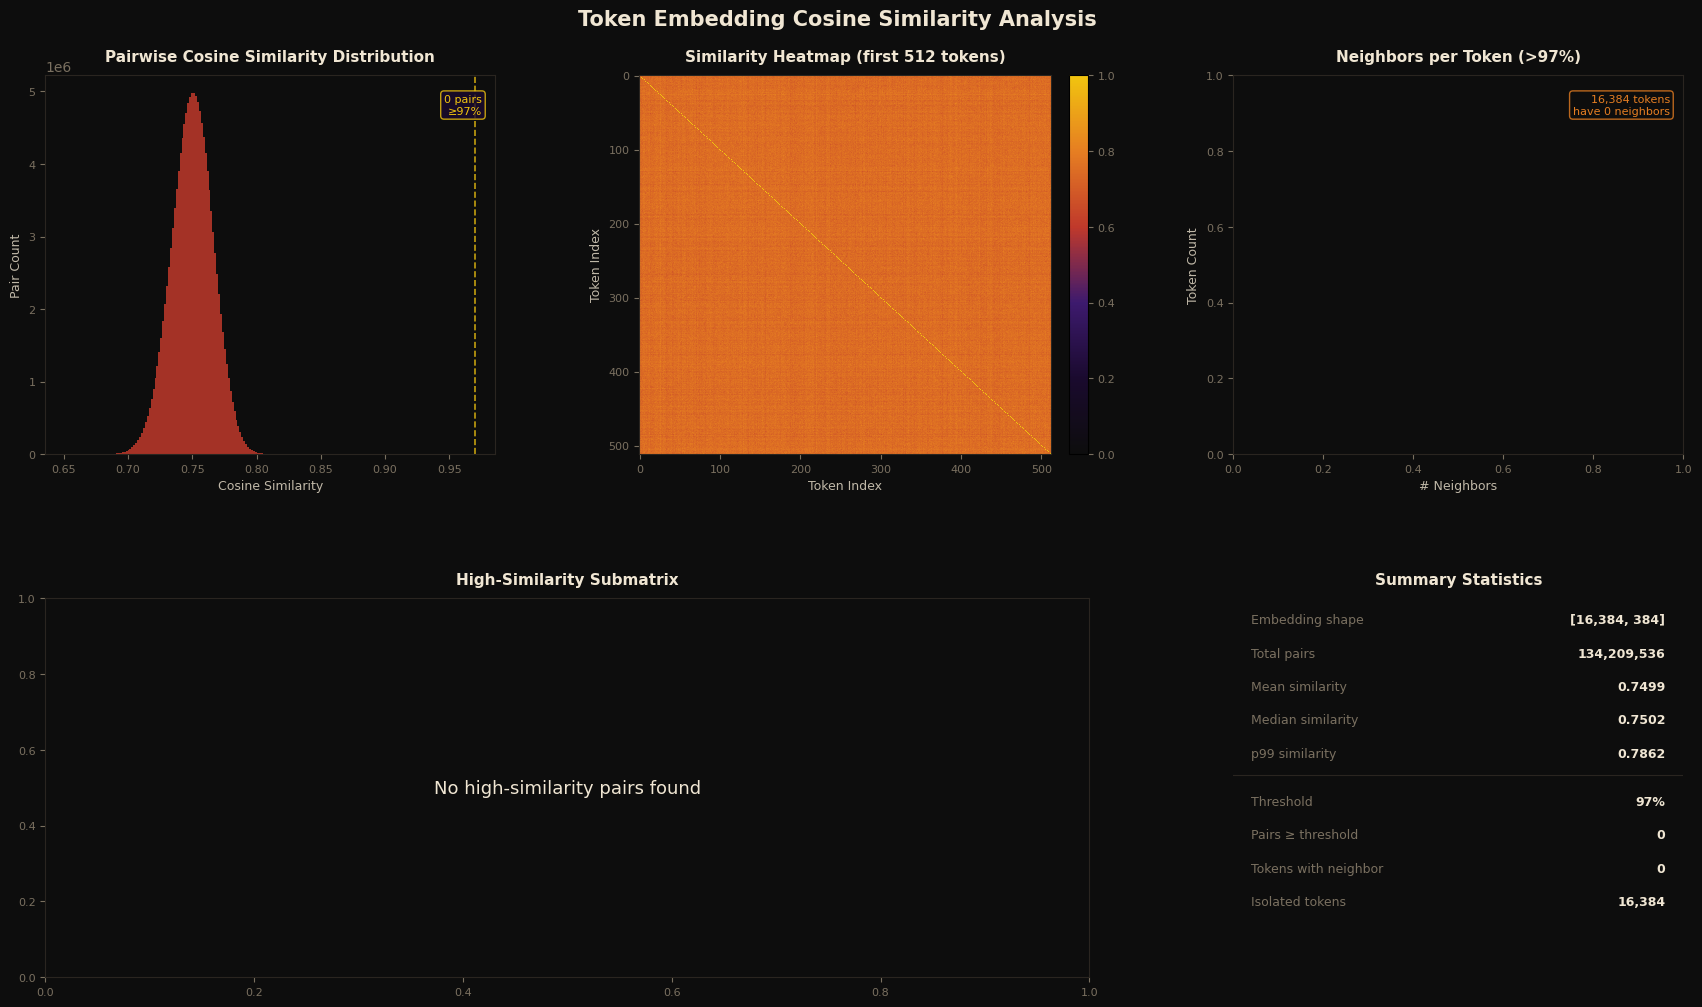

In [4]:
"""
cosine_similarity_analysis.py
──────────────────────────────
Computes all-pairs cosine similarity for a (N, D) token embedding tensor,
plots the distribution + a structural heatmap, and filters pairs > threshold.

Requires:
    embedding_tensor : torch.Tensor [N, D]
    tokenizer        : tokenizer object with get_vocab()
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import time

# ─── CONFIG ────────────────────────────────────────────────────────────────────
THRESHOLD       = 0.97       # similarity cutoff
HEATMAP_TOKENS  = 512        # how many tokens to show in the structural heatmap
BATCH_SIZE      = 512        # rows per batch for the full similarity computation
SAVE_PATH       = "cosine_analysis.png"
TOP_K_TOKENS    = 5          # top connected tokens to print
TOP_K_NEIGHBORS = 10         # neighbors printed per token
# ────────────────────────────────────────────────────────────────────────────────

# ── Inference ─────────────────────────────────────────────────────────────────
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("tokenizer/tokenizer.json")
# ─── REQUIRED DATA CHECK ────────────────────────────────────────────────────────
print("Checking required variables...")

if "embedding_tensor" not in globals():
    raise NameError(
        "embedding_tensor is not defined. "
        "Create/load your embedding_tensor before running this script."
    )

if "tokenizer" not in globals():
    raise NameError(
        "tokenizer is not defined. "
        "Load/create your tokenizer before running this script."
    )

print(f"  tensor shape : {embedding_tensor.shape}")
# ────────────────────────────────────────────────────────────────────────────────


# ─── TOKEN LOOKUP ───────────────────────────────────────────────────────────────
vocab = tokenizer.get_vocab()              # {token_str: token_id}
id_to_token = {v: k for k, v in vocab.items()}


def token_value(token_id: int) -> str:
    """
    Converts tokenizer ID into readable token text.

    Works well for ByteLevel BPE style tokens:
        Ġ  -> space
        Ċ  -> newline
    """
    tok = id_to_token.get(token_id, f"<missing:{token_id}>")

    tok = tok.replace("Ġ", " ")
    tok = tok.replace("Ċ", "\\n")

    return tok


def format_token(token_id: int, width: int = 22) -> str:
    """
    Pretty display for token id + token value.
    Uses repr() so spaces/newlines are visible.
    """
    value = repr(token_value(token_id))

    if len(value) > width:
        value = value[:width - 3] + "..."

    return f"token {token_id:5d} {value:<{width}}"
# ────────────────────────────────────────────────────────────────────────────────


def cosine_similarity_batched(embeddings: torch.Tensor, batch_size: int = 512):
    """
    Returns the full (N, N) cosine similarity matrix, computed in batches
    to avoid OOM on large tensors.

    Memory cost:
        N² × 4 bytes
        16384² × 4 ≈ 1 GB
    """
    # L2-normalise once — then cosine sim == dot product
    normed = torch.nn.functional.normalize(embeddings, p=2, dim=1)  # [N, D]
    N = normed.shape[0]
    sim = torch.zeros(N, N, dtype=torch.float32)

    t0 = time.time()

    for i in range(0, N, batch_size):
        batch = normed[i: i + batch_size]          # [B, D]
        sim[i: i + batch_size] = batch @ normed.T  # [B, N]

        if (i // batch_size) % 10 == 0:
            elapsed = time.time() - t0
            pct = min((i + batch_size) / N * 100, 100)
            print(f"  {pct:5.1f}%  {elapsed:.1f}s", end="\r")

    print(f"\n  Done in {time.time() - t0:.1f}s")

    return sim


def filter_high_similarity_pairs(sim: torch.Tensor, threshold: float = 0.90):
    """
    Returns:
        neighbors : dict[token_idx] -> list[(neighbor_idx, similarity_score)]
        rows      : source token ids
        cols      : neighbor token ids
        scores    : similarity scores

    Excludes the diagonal:
        self-similarity = 1.0
    """
    N = sim.shape[0]

    mask = sim > threshold
    mask.fill_diagonal_(False)

    rows, cols = torch.where(mask)
    scores = sim[rows, cols]

    neighbors = {}

    for r, c, s in zip(rows.tolist(), cols.tolist(), scores.tolist()):
        neighbors.setdefault(r, []).append((c, round(s, 4)))

    # Sort each neighbor list by descending similarity
    for k in neighbors:
        neighbors[k].sort(key=lambda x: -x[1])

    return neighbors, rows, cols, scores


def plot_analysis(
    sim: torch.Tensor,
    neighbors: dict,
    rows,
    cols,
    scores,
    threshold: float,
    heatmap_tokens: int = 512,
    save_path: str = None
):
    N = sim.shape[0]
    D = embedding_tensor.shape[1]
    total_pairs = N * (N - 1) // 2

    # ── flat upper-triangle for histogram, avoids double-counting
    idx_i, idx_j = torch.triu_indices(N, N, offset=1)
    all_sims = sim[idx_i, idx_j].numpy()

    # ── per-token neighbor counts
    counts = np.zeros(N, dtype=int)

    for k, v in neighbors.items():
        counts[k] = len(v)

    # ── colour map: dark background, warm gradient
    cmap_heat = LinearSegmentedColormap.from_list(
        "ember",
        ["#0d0d0d", "#1a0a2e", "#3d1a6e", "#c0392b", "#e67e22", "#f1c40f"]
    )

    fig = plt.figure(figsize=(18, 11), facecolor="#0d0d0d")

    gs = gridspec.GridSpec(
        2,
        3,
        figure=fig,
        left=0.06,
        right=0.97,
        top=0.91,
        bottom=0.09,
        hspace=0.38,
        wspace=0.32
    )

    title_kw = dict(color="#f0e6d3", fontsize=11, fontweight="bold", pad=10)
    label_kw = dict(color="#c0b8a8", fontsize=9)
    tick_kw = dict(colors="#7a7060", labelsize=8)
    spine_col = "#2a2520"

    def style_ax(ax):
        ax.set_facecolor("#0d0d0d")

        for spine in ax.spines.values():
            spine.set_color(spine_col)

        ax.tick_params(axis="both", **tick_kw)

    # ── 1. Histogram of all pairwise similarities
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1)

    n_bins = 120

    counts_hist, bin_edges, patches = ax1.hist(
        all_sims,
        bins=n_bins,
        color="#c0392b",
        alpha=0.85,
        edgecolor="none"
    )

    # Shade the >threshold zone
    for patch, left in zip(patches, bin_edges[:-1]):
        if left >= threshold:
            patch.set_facecolor("#f1c40f")
            patch.set_alpha(0.95)

    ax1.axvline(
        threshold,
        color="#f1c40f",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8
    )

    ax1.set_title("Pairwise Cosine Similarity Distribution", **title_kw)
    ax1.set_xlabel("Cosine Similarity", **label_kw)
    ax1.set_ylabel("Pair Count", **label_kw)

    above = (all_sims >= threshold).sum()

    ax1.text(
        0.97,
        0.95,
        f"{above:,} pairs\n≥{threshold:.0%}",
        transform=ax1.transAxes,
        color="#f1c40f",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#1a0a2e",
            ec="#f1c40f",
            alpha=0.8
        )
    )

    # ── 2. Structural heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2)

    sub = sim[:heatmap_tokens, :heatmap_tokens].numpy()

    im = ax2.imshow(
        sub,
        cmap=cmap_heat,
        vmin=0,
        vmax=1,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04).ax.tick_params(**tick_kw)

    ax2.set_title(f"Similarity Heatmap (first {heatmap_tokens} tokens)", **title_kw)
    ax2.set_xlabel("Token Index", **label_kw)
    ax2.set_ylabel("Token Index", **label_kw)

    # ── 3. Histogram of per-token neighbor count
    ax3 = fig.add_subplot(gs[0, 2])
    style_ax(ax3)

    non_zero_counts = counts[counts > 0]

    if len(non_zero_counts) > 0:
        ax3.hist(
            non_zero_counts,
            bins=40,
            color="#3d1a6e",
            edgecolor="#c0392b",
            linewidth=0.5,
            alpha=0.9
        )

    ax3.set_title(f"Neighbors per Token (>{threshold:.0%})", **title_kw)
    ax3.set_xlabel("# Neighbors", **label_kw)
    ax3.set_ylabel("Token Count", **label_kw)

    isolated = (counts == 0).sum()

    ax3.text(
        0.97,
        0.95,
        f"{isolated:,} tokens\nhave 0 neighbors",
        transform=ax3.transAxes,
        color="#e67e22",
        fontsize=8,
        ha="right",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="#0d0d0d",
            ec="#e67e22",
            alpha=0.8
        )
    )

    # ── 4. Filtered similarity matrix
    ax4 = fig.add_subplot(gs[1, :2])
    style_ax(ax4)

    high_tokens = sorted(set(rows.tolist()) | set(cols.tolist()))

    if len(high_tokens) > 1024:
        high_tokens = high_tokens[:1024]

    if len(high_tokens) > 1:
        idx_t = torch.tensor(high_tokens)
        sub_hi = sim[idx_t][:, idx_t].numpy()

        im2 = ax4.imshow(
            sub_hi,
            cmap=cmap_heat,
            vmin=threshold,
            vmax=1,
            aspect="auto",
            interpolation="nearest"
        )

        plt.colorbar(im2, ax=ax4, fraction=0.02, pad=0.02).ax.tick_params(**tick_kw)

        ax4.set_title(
            f"High-Similarity Submatrix — {len(high_tokens)} unique tokens with ≥{threshold:.0%} neighbor",
            **title_kw
        )

        ax4.set_xlabel("Filtered Token Index (rank)", **label_kw)
        ax4.set_ylabel("Filtered Token Index (rank)", **label_kw)

    else:
        ax4.text(
            0.5,
            0.5,
            "No high-similarity pairs found",
            transform=ax4.transAxes,
            color="#f0e6d3",
            ha="center",
            va="center",
            fontsize=13
        )

        ax4.set_title("High-Similarity Submatrix", **title_kw)

    # ── 5. Stats panel
    ax5 = fig.add_subplot(gs[1, 2])
    style_ax(ax5)
    ax5.axis("off")

    n_high_pairs = len(rows) // 2
    n_high_tokens = len(set(rows.tolist()))
    mean_sim = float(all_sims.mean())
    median_sim = float(np.median(all_sims))
    p99_sim = float(np.percentile(all_sims, 99))

    stats_lines = [
        ("Embedding shape", f"[{N:,}, {D}]"),
        ("Total pairs", f"{total_pairs:,}"),
        ("Mean similarity", f"{mean_sim:.4f}"),
        ("Median similarity", f"{median_sim:.4f}"),
        ("p99 similarity", f"{p99_sim:.4f}"),
        ("─" * 22, ""),
        ("Threshold", f"{threshold:.0%}"),
        ("Pairs ≥ threshold", f"{n_high_pairs:,}"),
        ("Tokens with neighbor", f"{n_high_tokens:,}"),
        ("Isolated tokens", f"{(counts == 0).sum():,}"),
    ]

    y = 0.96

    for label, value in stats_lines:
        if label.startswith("─"):
            ax5.axhline(y + 0.015, color=spine_col, linewidth=0.8)
            y -= 0.04
            continue

        ax5.text(
            0.04,
            y,
            label,
            transform=ax5.transAxes,
            color="#7a7060",
            fontsize=9,
            va="top"
        )

        ax5.text(
            0.96,
            y,
            value,
            transform=ax5.transAxes,
            color="#f0e6d3",
            fontsize=9,
            va="top",
            ha="right",
            fontweight="bold"
        )

        y -= 0.088

    ax5.set_title("Summary Statistics", **title_kw)

    fig.suptitle(
        "Token Embedding Cosine Similarity Analysis",
        color="#f0e6d3",
        fontsize=15,
        fontweight="bold",
        y=0.97
    )

    plt.savefig(
        save_path or SAVE_PATH,
        dpi=150,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    print(f"\nPlot saved → {save_path or SAVE_PATH}")
    plt.show()


# ─── MAIN ──────────────────────────────────────────────────────────────────────
print("\n[1/3] Computing full cosine similarity matrix …")

sim = cosine_similarity_batched(embedding_tensor, batch_size=BATCH_SIZE)

print(f"\n[2/3] Filtering pairs with similarity > {THRESHOLD} …")

neighbors, rows, cols, scores = filter_high_similarity_pairs(sim, THRESHOLD)

# ── what you "keep": a mapping from each token to its close neighbors
print(f"  Tokens with at least one neighbor : {len(neighbors):,}")
print(f"  Total directed edges              : {len(rows):,}")

# ── Print top connected tokens with token values
print(f"\n  Top-{TOP_K_TOKENS} most-connected tokens with token values:")

top_tokens = sorted(neighbors.items(), key=lambda x: -len(x[1]))[:TOP_K_TOKENS]

for tok_id, nbrs in top_tokens:
    tok_text = token_value(tok_id)

    print("\n" + "─" * 80)
    print(f"  {format_token(tok_id)}")
    print(f"  neighbors : {len(nbrs):,}")
    print(f"  top sim   : {nbrs[0][1]:.4f}")
    print(f"  top token : {format_token(nbrs[0][0])}")
    print("\n  Top neighbors:")

    for rank, (nb_id, sim_score) in enumerate(nbrs[:TOP_K_NEIGHBORS], start=1):
        print(
            f"    {rank:2d}. {format_token(nb_id)} "
            f"sim = {sim_score:.4f}"
        )

print("\n" + "─" * 80)

# ── kept_embeddings: the subset of embeddings involved in high-sim pairs
kept_indices = sorted(set(rows.tolist()) | set(cols.tolist()))
kept_embeddings = embedding_tensor[kept_indices]

print(f"\n  kept_embeddings.shape : {kept_embeddings.shape}")

# ── Optional: print kept token ids + values
print("\n  Sample kept token indices with values:")

for idx in kept_indices[:25]:
    print(f"    {format_token(idx)}")

if len(kept_indices) > 25:
    print(f"    ... and {len(kept_indices) - 25:,} more")

print("\n[3/3] Plotting …")

plot_analysis(
    sim,
    neighbors,
    rows,
    cols,
    scores,
    threshold=THRESHOLD,
    heatmap_tokens=HEATMAP_TOKENS,
    save_path=SAVE_PATH
)

In [6]:
from torch.utils.data import Dataset
SEQ_LEN = 512
STRIDE = 512

class ShardDataset(Dataset):
    def __init__(self, shard_path, seq_len=SEQ_LEN, stride=STRIDE):
        flat = torch.load(shard_path, weights_only=True)

        self.flat    = flat.to(torch.int16)
        # self.flat    = self.flat[:10000]
        self.seq_len = seq_len
        self.stride  = stride

        # number of full windows we can extract
        # +1 because we need seq_len+1 tokens (x + y target)
        n_tokens = len(self.flat)
        self.num_samples = max(0, (n_tokens - seq_len - 1) // stride + 1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start  = idx * self.stride
        tokens = self.flat[start : start + self.seq_len + 1].to(torch.long)  # ← cast here
        
        if len(tokens) < self.seq_len + 1:
            pad    = torch.full((self.seq_len + 1 - len(tokens),), PAD_ID, dtype=torch.long)
            tokens = torch.cat([tokens, pad])

        x = tokens[:-1]
        y = tokens[1:]
        return x, y


BOS_ID       = 2
EOS_ID       = 3

def collate_fn(batch):
    xs, ys = zip(*batch)
    # all samples are now fixed-length (seq_len), so no padding needed here
    x_pad = torch.stack(xs)          # [B, seq_len]
    y_pad = torch.stack(ys).clone()  # [B, seq_len]

    # mask out targets after the first EOS in each sequence
    for i, y in enumerate(y_pad):
        eos_positions = (y == EOS_ID).nonzero(as_tuple=True)[0]
        if len(eos_positions) > 0:
            eos_pos = eos_positions[0].item()
            if eos_pos + 1 < y.size(0):
                y_pad[i, eos_pos + 1:] = -100

    return x_pad, y_pad

In [10]:

from pathlib import Path

SHARD_DIR  = Path("dataset_shards")

In [11]:
s = [ShardDataset(p) for p in sorted(SHARD_DIR.glob("shard_*.pt"))[:1]]
s

In [14]:
from torch.utils.data import Dataset
SEQ_LEN = 512
STRIDE = 512

class ShardDataset(Dataset):
    def __init__(self, shard_path, seq_len=SEQ_LEN, stride=STRIDE):
        flat = torch.load(shard_path, weights_only=True)

        self.flat    = flat.to(torch.int16)
        # self.flat    = self.flat[:10000]
        self.seq_len = seq_len
        self.stride  = stride

        # number of full windows we can extract
        # +1 because we need seq_len+1 tokens (x + y target)
        n_tokens = len(self.flat)
        self.num_samples = max(0, (n_tokens - seq_len - 1) // stride + 1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start  = idx * self.stride
        tokens = self.flat[start : start + self.seq_len + 1].to(torch.long)  # ← cast here
        
        if len(tokens) < self.seq_len + 1:
            pad    = torch.full((self.seq_len + 1 - len(tokens),), PAD_ID, dtype=torch.long)
            tokens = torch.cat([tokens, pad])

        x = tokens[:-1]
        y = tokens[1:]
        return x, y


BOS_ID       = 2
EOS_ID       = 3

def collate_fn(batch):
    xs, ys = zip(*batch)
    # all samples are now fixed-length (seq_len), so no padding needed here
    x_pad = torch.stack(xs)          # [B, seq_len]
    y_pad = torch.stack(ys).clone()  # [B, seq_len]

    # mask out targets after the first EOS in each sequence
    for i, y in enumerate(y_pad):
        eos_positions = (y == EOS_ID).nonzero(as_tuple=True)[0]
        if len(eos_positions) > 0:
            eos_pos = eos_positions[0].item()
            if eos_pos + 1 < y.size(0):
                y_pad[i, eos_pos + 1:] = -100

    return x_pad, y_pad
    
s = [ShardDataset(p) for p in sorted(SHARD_DIR.glob("shard_*.pt"))[:1]]
s
s[0].num_samples
524289


524289

In [15]:
524289*512, 268435968


268435968